In [1]:
import torch
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import PolynomialLR
from torch.utils.data import WeightedRandomSampler
from torchvision.transforms import v2

import albumentations as A
from albumentations.pytorch import ToTensorV2

from tqdm.notebook import tqdm
import json
import cv2
import matplotlib.pyplot as plt
import numpy as np
###IE###
%load_ext autoreload
%autoreload 2
from utils.helpers import (
    plot_some_images ,read_images ,
    pre_hard_skeletonize , pre_soft_skeletonize,
    compute_confution_matrix,draw_mask,
    denorm)
from utils.preprocessing import WhiteTopHat , CLAHE , normalize_xca
from utils.dataset import  UnetDataset , ValidUnetDataset
from models.nnunet import nnUnet
from models.nnunet_blocks import nnUnetv2
from models.swin_encoder import SwinEncoder , SwinUperNet
from utils.losses import MainLossFn
from utils.recorder import HistoryRecorder
from logger import save_full_report
from trainer import trainer
###SS###

# Training

In [2]:
args = {
    "base_path" : "./dataset/syntax",
    "in_c" : 3,
    "base_channel" :32,
    "image_shape" : (448,448),
    "class_count" : 26 ,
    "abs_class_count":17,
    "attention" : True,
    "k":40,
    "batch_size" : 4,
    "num_workers" : 5,
    "device" : "cuda" if torch.cuda.is_available() else "cpu",
    "lr" : 1e-4,
    "momentum" : 0.99,
    "weight_decay" : 0.001,
    "epcohs":30,
    "f_int_scale" : 2,
    "full_report_cycle" : 10,
    "max_channels":512,
    "unet_depth":6,
    "loss_type":"tversky loss",
    "alpha":0.3,
    "beta":0.7,
    "t_gamma":2.0,
    "f_gamma":2.0,
    "resize_binary":[True,(192,192)],
    "loss_coefs":{"CE":1.0,"Second":1.0},
    "swin_head" : "costume",
    "swin_type":"swin_v2_b",
    "output_base_path" : "./outputs",
    "name" : "swin-multi_task-main_label",
    "deep_super_vision" : False,
    "use_sch":False,
    "use_amp":False,
    "f_alpha":None
}
class_map = {
    1: '1',2: '2', 3: '3',4: '4',
    5: '5',6: '6',7: '7',8: '8',
    9: '9',10: '9a',11: '10',12: '10a',
    13: '11',14: '12',15: '12a',16: '13',
    17: '14',18: '14a',19: '15',20: '16',
    21: '16a',22: '16b',23: '16c',
    24: '12b',25: '14b'
}
abs_class_map = [
    1,2,3,4,5,6,7,
    8,9,9,10,10,11,
    12,12,13,14,14,
    15,16,16,16,16,
    12,14
]
"""
    1:1,
    2:2,
    3:3,
    4:4,
    5:5,
    6:6,
    7:7,
    8:8,
    9:9,
    10:9,
    11:10,
    12:10,
    13:11,
    14:12,
    15:12,
    16:13,
    17:14,
    18:14,
    19:15,
    20:16,
    21:16,
    22:16,
    23:16,
    24:12,
    25:14
"""
train_class_counts = [
    1000,374,375,369,303,525,525,
    340,310,198,70,21,1,320,61,
    129,305,107,49,38,232,43,48,31,63,127
]
train_pixel_counts = [
    253576361,664435,686727,661957,
    480566,591829,816901,685677,570436,
    470633,124025,23866,1079,507754,151219,
    336857,597880,241117,98167,66890,322098,
    49426,63543,36457,164558,153542
]
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
# losses_keys = ["total loss","FCE loss",args["loss_type"]]

losses_keys = [
    "total loss",
    "label loss",
    # "binary loss",
    # f"{args["loss_type"]}_abs",
    f"{args["loss_type"]}_main",
]
out_counts = 5 if args["deep_super_vision"] else 1
loss_weights = [1/(2**i) for i in range(out_counts)]
loss_weights

[1.0]

In [3]:
def class_weighting(method,class_counts,**kwargs):
    if(kwargs["use_pixel_counts"]):
        print("using pixel counts")
        with open("./data/train_pixel_counts.json","r") as f:
            train_class_counts = json.load(f)
        counts = [0]*(len(train_class_counts))
        for k,v in train_class_counts.items():
            counts[int(k)] = int(v)
        counts = np.array(counts,dtype=np.float64)
    else :
        print("using class counts")
        counts = np.array(class_counts,dtype=np.float64)

    if(method=="median"):
        print("median weights being used")
        median_count = np.median(counts)
        weights = median_count/np.array(counts)
        
    elif(method=="log"):
        print("log weights being used")
        total = np.sum(counts)
        weights = np.log(total/np.array(counts))
        weights = (weights / weights.mean())
        weights[0]=0.1
    elif(method=="beta"):
        print("beta weights being used")
        b = kwargs["b"]
        weights = (1-b)/(1-np.power(b,counts))
        weights = weights / weights.sum()
        weights[12] = 0.25
    else:
        print("no class weights being used")
        return None
    return weights.tolist()
args["f_alpha"] = class_weighting(method="none",class_counts=train_class_counts,b=0.999999,use_pixel_counts=False)
args["f_alpha"]

using class counts
no class weights being used


In [4]:
# pre_soft_skeletonize(args["base_path"],output_path=args["base_path"],batch_size=10,k=40)

In [5]:
def morph_binary_mask(x, **kwargs):
    m = x.copy()

    if m.ndim == 3:
        m2 = m[..., 0]
    else:
        m2 = m

    m2 = (m2 > 0).astype(np.uint8)

    if np.random.rand() < 0.5:
        k = np.ones((3, 3), np.uint8)
        if np.random.rand() < 0.5:
            m2 = cv2.dilate(m2, k, iterations=1)
        else:
            m2 = cv2.erode(m2, k, iterations=1)

    if np.random.rand() < 0.5:
        blurred = cv2.GaussianBlur(m2.astype(np.float32), (3, 3), 0)
        m2 = (blurred > 0.5).astype(np.uint8)

    if np.random.rand() < 0.5:
        h, w = m2.shape        
        for _ in range(200):
            y = np.random.randint(0, h)
            x = np.random.randint(0, w)
            m2[y, x] = 0

    
    if m.ndim == 3:
        m_out = m2[..., None]
    else:
        m_out = m2

    return m_out

In [6]:
train_transforms = A.Compose([
    # A.RandomCrop(args["image_shape"][0],args["image_shape"][1]),
    A.Resize(*args["image_shape"]),
    A.OneOf([
        A.ElasticTransform(
            alpha=120, 
            sigma=120 * 0.05, 
            p=1.0
        ),
        A.GridDistortion(num_steps=5, distort_limit=0.3, p=1.0),
        A.OpticalDistortion(distort_limit=0.2, p=1.0),
    ], p=0.7),


    A.Affine(
        scale=(0.8, 1.2),             
        translate_percent=(-0.1, 0.1), 
        rotate=(-30, 30),         
        shear=(-10, 10),      
        

        fill=0,           
        fill_mask=0,                 
        border_mode=cv2.BORDER_CONSTANT, 
        
        fit_output=False,  
        p=0.7
    ),

    # A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=0.5),

    # A.RandomBrightnessContrast(
    #     brightness_limit=0.2, 
    #     contrast_limit=0.2, 
    #     p=0.5
    # ),

    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    # A.Lambda(image=morph_binary_mask, p=1),

    # A.Lambda(image=normalize_xca)
    A.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
        max_pixel_value=255.0
    )

],additional_targets={'binary_mask': 'mask', 'abs_mask': 'mask','skel_img':'mask'})

test_transforms = A.Compose([
    # A.RandomCrop(args["image_shape"][0],args["image_shape"][1]),
    A.Resize(*args["image_shape"]),
    # A.Lambda(image=normalize_xca),
    A.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
        max_pixel_value=255.0
    )
],additional_targets={'binary_mask': 'mask', 'abs_mask': 'mask','skel_img':'mask'})
# train_preprocess = v2.Compose([
#     WhiteTopHat(kernel_size=(50,50)),
#     CLAHE()
    
# ])
train_preprocess = None


In [7]:
def make_dataloader(data,args,valid=False,sampler_weights=None):
    if(sampler_weights is not None):
        print("using weighted sampler here")
        sampler = WeightedRandomSampler(sampler_weights, len(sampler_weights))
        dataloader = DataLoader(
            data,
            batch_size = args["batch_size"] ,
            num_workers = args["num_workers"] ,
            pin_memory=True,
            shuffle=False,
            sampler=sampler
        )
        
    else : 
        if(valid):
            print("valid with no sampler")
            dataloader = DataLoader(
                data,
                batch_size = args["batch_size"] ,
                num_workers = args["num_workers"] ,
                pin_memory=True,
                shuffle=False,
            )
        else : 
            print("train with no sampler")
            dataloader = DataLoader(
                data,
                batch_size = args["batch_size"] ,
                num_workers = args["num_workers"] ,
                pin_memory=True,
                shuffle=True
            )
    return dataloader

In [8]:

train_images,sampler_weights = read_images(
    base_path = args["base_path"],
    preprocessor = train_preprocess,
    part = "train",
    train_class_counts=np.array(train_pixel_counts),
    in_c = args["in_c"],
    abs_class_map = abs_class_map,
    resize_binary = args["resize_binary"],
    k = args["k"]
)
valid_images = read_images(
    base_path = args["base_path"],
    preprocessor = train_preprocess,
    part = "val",
    train_class_counts=None,
    in_c=args["in_c"],
    abs_class_map = abs_class_map,
    resize_binary = args["resize_binary"],
    k = args["k"]
)
# print(sampler_weights)
train_ds = UnetDataset(
    transform = train_transforms,
    data = train_images,
    base_size=args["image_shape"]
)
valid_ds = UnetDataset(
    transform = test_transforms,
    data = valid_images,
    base_size=args["image_shape"]
)

train_loader = make_dataloader(train_ds,args,valid=False,sampler_weights=sampler_weights)
valid_loader = make_dataloader(valid_ds,args,valid=True,sampler_weights=None)

max count is :  816901
NOTE : preprocessor is not defined . no preprocessing will be used !


  0%|          | 0/1000 [00:00<?, ?it/s]

NOTE : preprocessor is not defined . no preprocessing will be used !


  0%|          | 0/200 [00:00<?, ?it/s]

using weighted sampler here
valid with no sampler


torch.Size([4, 3, 448, 448])
torch.Size([4, 1])
torch.Size([4, 1, 224, 224])
torch.Size([4, 448, 448])
torch.Size([4, 448, 448])
torch.Size([4, 1, 224, 224])
[0 1]
[0 6 7 8]
[0 6 7 8]


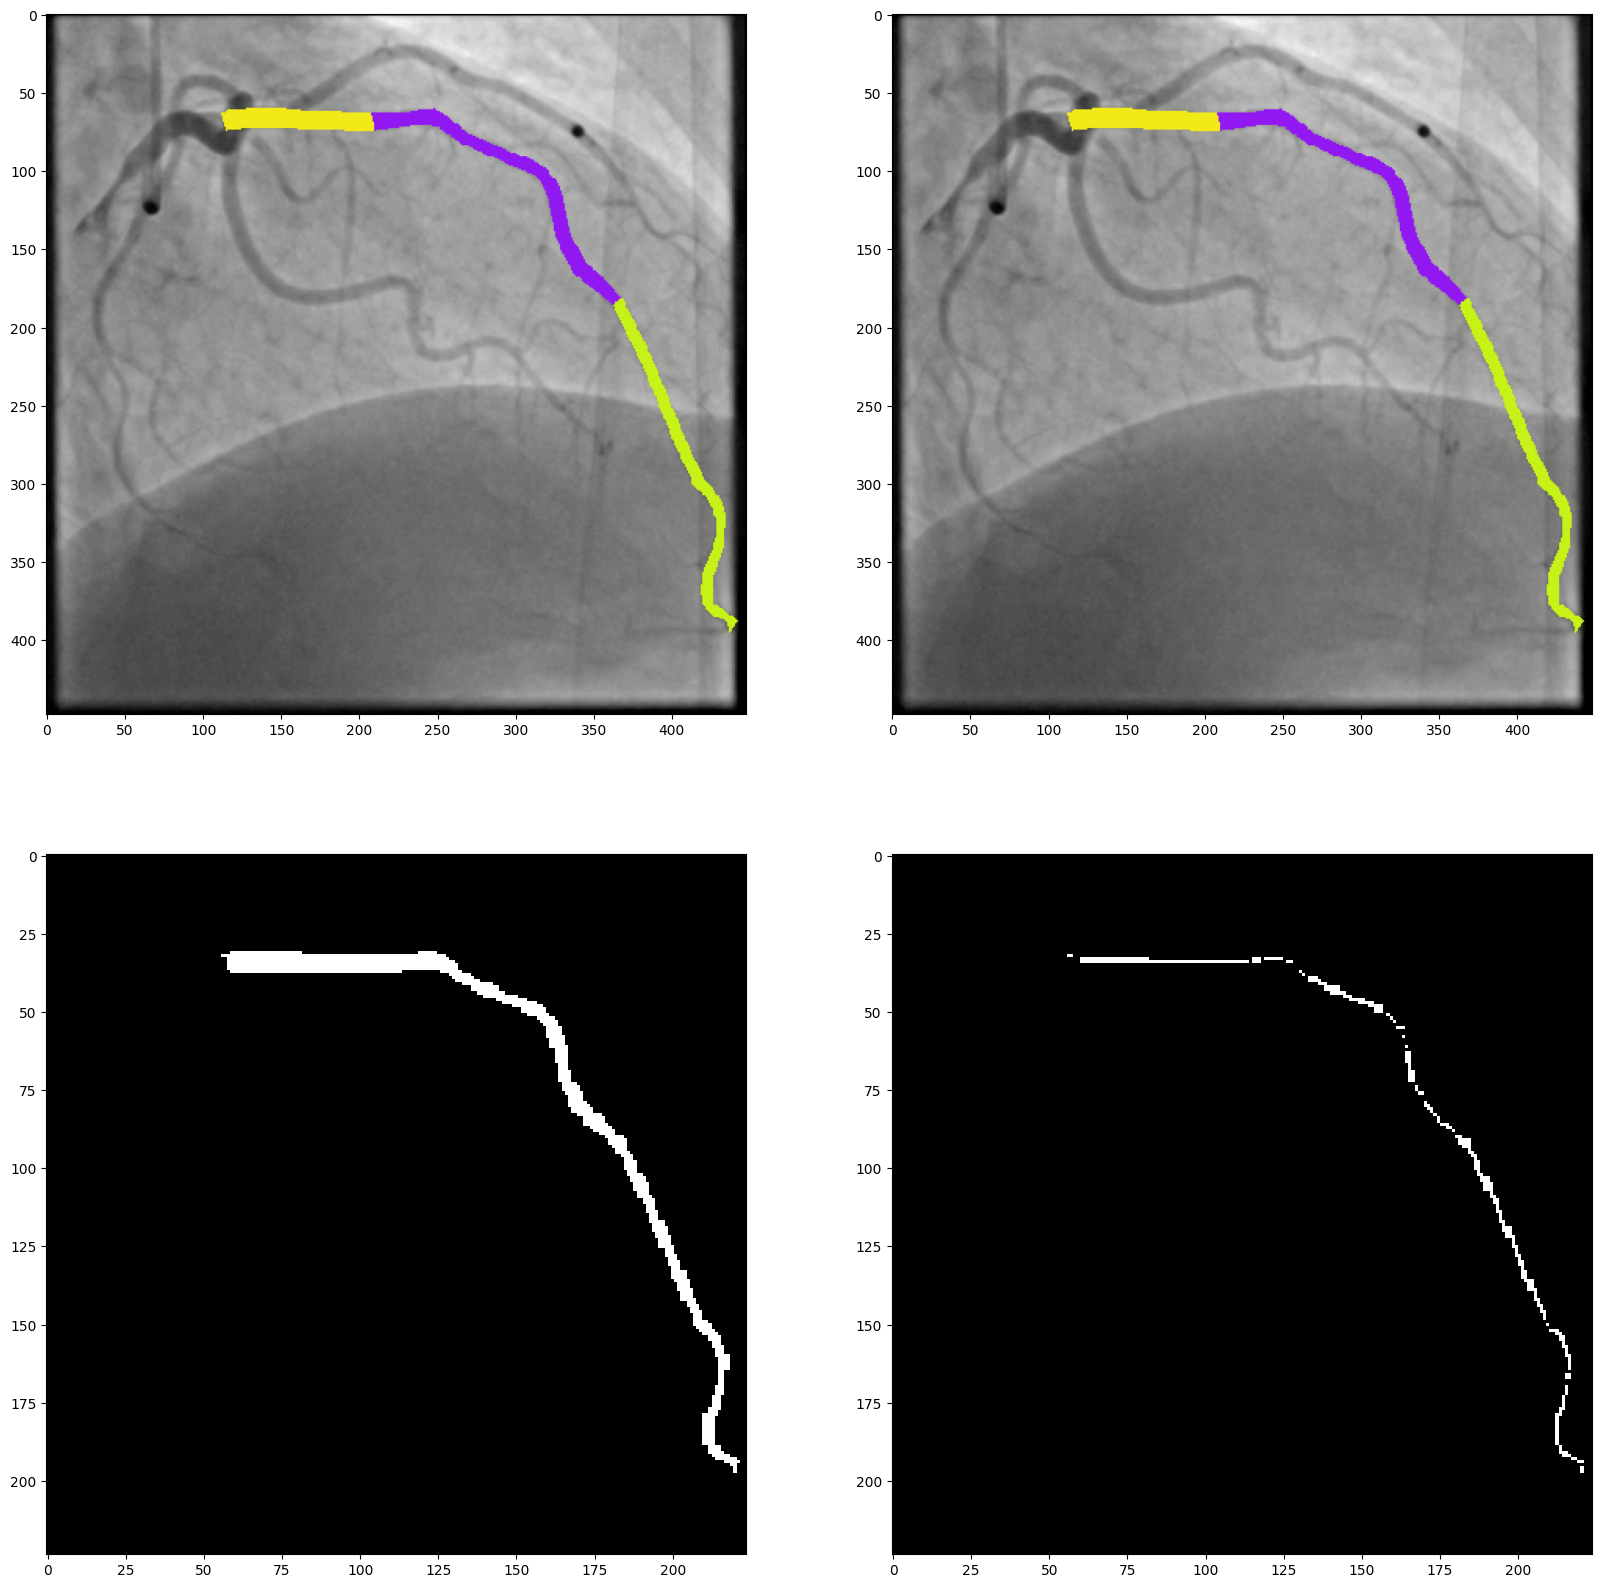

In [9]:
colors = np.array([
    (242,  24,  24),   # Red
    (242,  77,  24),   # Red-Orange
    (242, 129,  24),   # Orange
    (242, 181,  24),   # Yellow-Orange
    ( 24, 242, 216),   # Cyan
    (242, 234,  24),   # Yellow
    (146,  24, 242),   # Purple
    (199, 242,  24),   # Yellow-Green
    (146, 242,  24),   # Lime
    ( 94, 242,  24),   # Green
    (242,  24, 181),   # Fuchsia
    ( 42, 242,  24),   # Green (brighter)
    ( 94,  24, 242),   # Violet
    ( 24, 242,  59),   # Spring Green
    (242,  24, 129),   # Pink
    ( 24, 242, 111),   # Aquamarine
    ( 24, 242, 164),   # Turquoise
    ( 24, 164, 242),   # Azure
    (199,  24, 242),   # Magenta
    ( 24, 216, 242),   # Sky Blue
    ( 24, 111, 242),   # Blue
    (242,  24, 234),   # Hot Pink
    ( 24,  59, 242),   # Royal Blue
    ( 42,  24, 242),   # Indigo
    (242,  24,  77),   # Rose
], dtype=np.uint8)

for img,side_label,binary_mask,abs_mask,mask,skel_img in valid_loader:
    print(img.shape)
    print(side_label.shape)
    print(binary_mask.shape)
    print(abs_mask.shape)
    print(mask.shape)
    print(skel_img.shape)
    ### binary check 
    index=1
    print(np.unique(binary_mask[index].numpy()))
    ### abs check 
    img = denorm(img[index],mean=IMAGENET_MEAN,std=IMAGENET_STD)
    plt.figure(figsize=(20,20))
    plt.subplot(2,2,1)
    print(np.unique(abs_mask[index].numpy()))
    print(np.unique(mask[index].numpy()))
    colored_16 = draw_mask(image=img,mask=abs_mask[index].numpy(),colors=colors)
    plt.imshow(colored_16)
    plt.subplot(2,2,2)
    colored_25 = draw_mask(image=img,mask=mask[index].numpy(),colors=colors)
    plt.imshow(colored_25)
    plt.subplot(2,2,3)
    plt.imshow(binary_mask[index][0].numpy(),cmap="gray")
    plt.subplot(2,2,4)
    plt.imshow((skel_img[index][0].numpy()>=0.5).astype(np.uint8),cmap="gray")
    break

In [10]:
# plot_some_images(train_images, train_transforms, mean=IMAGENET_MEAN,std=IMAGENET_STD,image_counts=36, fig_shape=(6,6), base_transforms=test_transforms)

In [11]:
model = SwinEncoder(args).to(args["device"])

loss_fn = MainLossFn(args)
# optimizer = torch.optim.Adam(model.parameters(), lr=args["lr"])
# optimizer = torch.optim.SGD(
#     model.parameters(),
#     momentum=args["momentum"],
#     lr=args["lr"],
#     nesterov=True,
#     weight_decay=args["weight_decay"]
# )
optimizer = torch.optim.AdamW(
    model.parameters(), 
    lr=args["lr"], 
    betas=(0.9, 0.999), 
    eps=1e-08, 
    weight_decay=args["weight_decay"]
)
if(args["use_sch"]):
    lr_sch = PolynomialLR(optimizer=optimizer,total_iters=args["epcohs"],power=0.9)
else:
    lr_sch = None
recorder = HistoryRecorder(losses_keys=losses_keys,class_maps =class_map)

best_model =trainer(
    args=args,
    recorder = recorder,
    model = model,
    optimizer = optimizer,
    loss_fn = loss_fn,
    train_loader = train_loader,
    valid_loader = valid_loader,
    loss_weights=loss_weights,
    lr_sch = lr_sch
)
#NON-FINITE GRAD IN: backbone.features.5.0.attn.qkv.weight

loss is set to tversky


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

--- Total Norm ---
tensor(5.1883, device='cuda:0', grad_fn=<AddBackward0>) tensor(2.1795, device='cuda:0')
--- Total Norm ---
tensor(3.2413, device='cuda:0', grad_fn=<AddBackward0>) tensor(4.1743, device='cuda:0')
--- Total Norm ---
tensor(3.7682, device='cuda:0', grad_fn=<AddBackward0>) tensor(3.8869, device='cuda:0')
--- Total Norm ---
tensor(2.0325, device='cuda:0', grad_fn=<AddBackward0>) tensor(3.7541, device='cuda:0')
--- Total Norm ---
tensor(3.1052, device='cuda:0', grad_fn=<AddBackward0>) tensor(3.5325, device='cuda:0')
--- Total Norm ---
tensor(3.0906, device='cuda:0', grad_fn=<AddBackward0>) tensor(3.3912, device='cuda:0')
--- Total Norm ---
tensor(1.6855, device='cuda:0', grad_fn=<AddBackward0>) tensor(3.3209, device='cuda:0')
--- Total Norm ---
tensor(2.2335, device='cuda:0', grad_fn=<AddBackward0>) tensor(2.9398, device='cuda:0')
--- Total Norm ---
tensor(2.7774, device='cuda:0', grad_fn=<AddBackward0>) tensor(2.5045, device='cuda:0')
--- Total Norm ---
tensor(2.7161, dev

  0%|          | 0/250 [00:00<?, ?it/s]

...

--- Total Norm ---
tensor(0.7247, device='cuda:0', grad_fn=<AddBackward0>) tensor(0.9544, device='cuda:0')
--- Total Norm ---
tensor(1.2083, device='cuda:0', grad_fn=<AddBackward0>) tensor(1.0734, device='cuda:0')
--- Total Norm ---
tensor(1.2978, device='cuda:0', grad_fn=<AddBackward0>) tensor(2.0351, device='cuda:0')
--- Total Norm ---
tensor(1.2218, device='cuda:0', grad_fn=<AddBackward0>) tensor(1.4473, device='cuda:0')
--- Total Norm ---
tensor(1.8908, device='cuda:0', grad_fn=<AddBackward0>) tensor(0.7107, device='cuda:0')
--- Total Norm ---
tensor(1.2502, device='cuda:0', grad_fn=<AddBackward0>) tensor(0.9604, device='cuda:0')
--- Total Norm ---
tensor(1.2506, device='cuda:0', grad_fn=<AddBackward0>) tensor(2.0402, device='cuda:0')
--- Total Norm ---
tensor(1.1586, device='cuda:0', grad_fn=<AddBackward0>) tensor(1.2083, device='cuda:0')
--- Total Norm ---
tensor(0.6836, device='cuda:0', grad_fn=<AddBackward0>) tensor(0.7696, device='cuda:0')
--- Total Norm ---
tensor(2.7320, dev

  0%|          | 0/250 [00:00<?, ?it/s]

--- Total Norm ---
tensor(0.7116, device='cuda:0', grad_fn=<AddBackward0>) tensor(0.7930, device='cuda:0')
--- Total Norm ---
tensor(1.3490, device='cuda:0', grad_fn=<AddBackward0>) tensor(0.9771, device='cuda:0')
--- Total Norm ---
tensor(2.6563, device='cuda:0', grad_fn=<AddBackward0>) tensor(0.7629, device='cuda:0')
--- Total Norm ---
tensor(1.9591, device='cuda:0', grad_fn=<AddBackward0>) tensor(0.7551, device='cuda:0')
--- Total Norm ---
tensor(1.1411, device='cuda:0', grad_fn=<AddBackward0>) tensor(0.6630, device='cuda:0')
--- Total Norm ---
tensor(0.7432, device='cuda:0', grad_fn=<AddBackward0>) tensor(1.8262, device='cuda:0')
--- Total Norm ---
tensor(1.9285, device='cuda:0', grad_fn=<AddBackward0>) tensor(2.3136, device='cuda:0')
--- Total Norm ---
tensor(0.7628, device='cuda:0', grad_fn=<AddBackward0>) tensor(0.9204, device='cuda:0')
--- Total Norm ---
tensor(1.2347, device='cuda:0', grad_fn=<AddBackward0>) tensor(0.8419, device='cuda:0')
--- Total Norm ---
tensor(1.1599, dev

  0%|          | 0/250 [00:00<?, ?it/s]

--- Total Norm ---
tensor(0.7862, device='cuda:0', grad_fn=<AddBackward0>) tensor(0.9626, device='cuda:0')
--- Total Norm ---
tensor(1.8789, device='cuda:0', grad_fn=<AddBackward0>) tensor(0.9480, device='cuda:0')
--- Total Norm ---
tensor(2.6839, device='cuda:0', grad_fn=<AddBackward0>) tensor(1.0098, device='cuda:0')
--- Total Norm ---
tensor(2.7602, device='cuda:0', grad_fn=<AddBackward0>) tensor(1.9019, device='cuda:0')
--- Total Norm ---
tensor(2.7128, device='cuda:0', grad_fn=<AddBackward0>) tensor(1.3323, device='cuda:0')
--- Total Norm ---
tensor(1.2600, device='cuda:0', grad_fn=<AddBackward0>) tensor(1.7473, device='cuda:0')
--- Total Norm ---
tensor(1.1888, device='cuda:0', grad_fn=<AddBackward0>) tensor(1.2226, device='cuda:0')
current lr : 0.0001
train ==> epcoh (29)
total loss : 1.5103910269737244 - label loss : 6.134090661743805 - tversky loss_main : 0.5902773888111115

train avg metrics for epoch 29 :
avg dice : 0.389499069727053 - avg precision : 0.3919156908988953 - av

Save Model
Saving Memory
Saving All Plots
Saving Examples
torch.Size([3, 448, 448])
(448, 448)
(448, 448)
torch.Size([3, 448, 448])
(448, 448)
(448, 448)
torch.Size([3, 448, 448])
(448, 448)
(448, 448)
torch.Size([3, 448, 448])
(448, 448)
(448, 448)
torch.Size([3, 448, 448])
(448, 448)
(448, 448)
torch.Size([3, 448, 448])
(448, 448)
(448, 448)
torch.Size([3, 448, 448])
(448, 448)
(448, 448)
torch.Size([3, 448, 448])
(448, 448)
(448, 448)
torch.Size([3, 448, 448])
(448, 448)
(448, 448)
torch.Size([3, 448, 448])
(448, 448)
(448, 448)
torch.Size([3, 448, 448])
(448, 448)
(448, 448)
torch.Size([3, 448, 448])
(448, 448)
(448, 448)
torch.Size([3, 448, 448])
(448, 448)
(448, 448)
torch.Size([3, 448, 448])
(448, 448)
(448, 448)
torch.Size([3, 448, 448])
(448, 448)
(448, 448)
torch.Size([3, 448, 448])
(448, 448)
(448, 448)
torch.Size([3, 448, 448])
(448, 448)
(448, 448)
torch.Size([3, 448, 448])
(448, 448)
(448, 448)
Saving Verbal Results
Copying Notebook To Results
builfding kaggle project


100%|██████████| 11/11 [00:00<00:00, 3452.88it/s]


processing ./utils/dataset.py
processing ./utils/helpers.py
processing ./logger.py
processing ./utils/preprocessing.py
processing ./utils/recorder.py
processing ./models/costume_nnunet_blocks.py
processing ./models/nnunet.py
processing ./models/swin_encoder.py
processing ./models/swin_blocks.py
processing ./utils/losses.py
processing ./trainer.py


100%|██████████| 1/1 [00:00<00:00,  5.12it/s]


processing ./temp_script.py


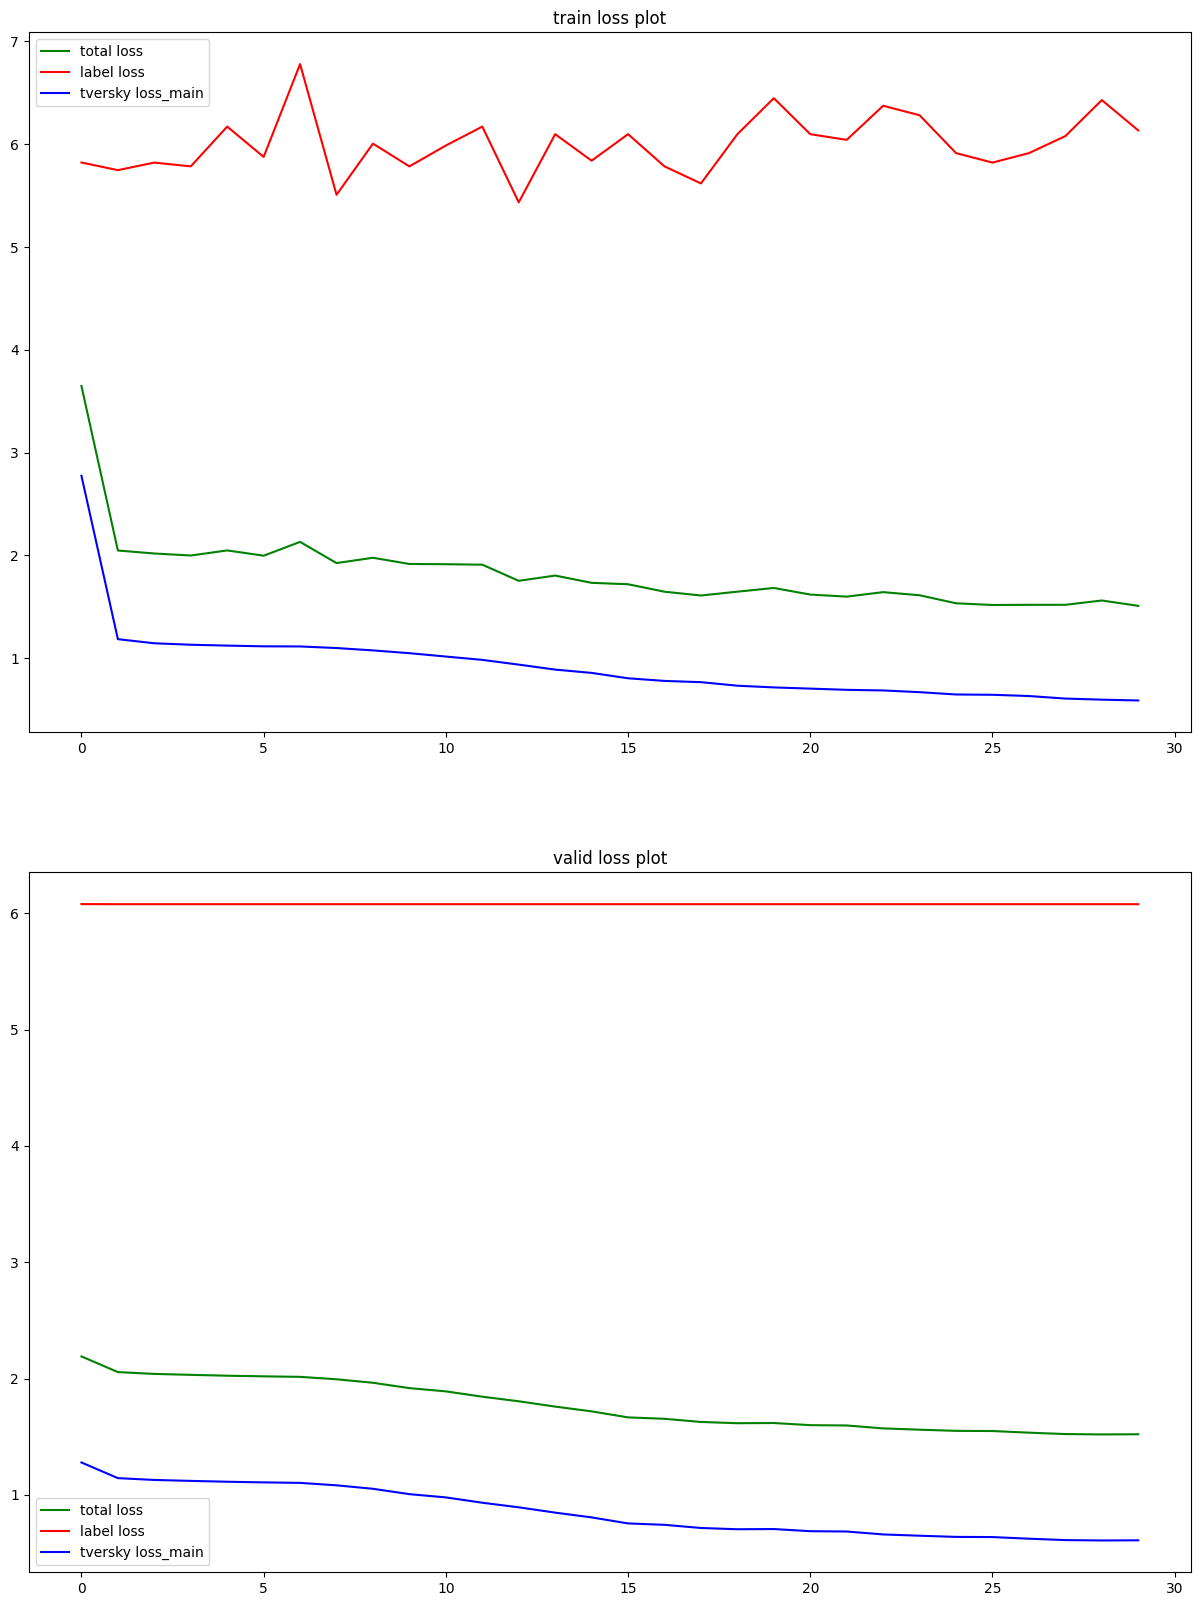

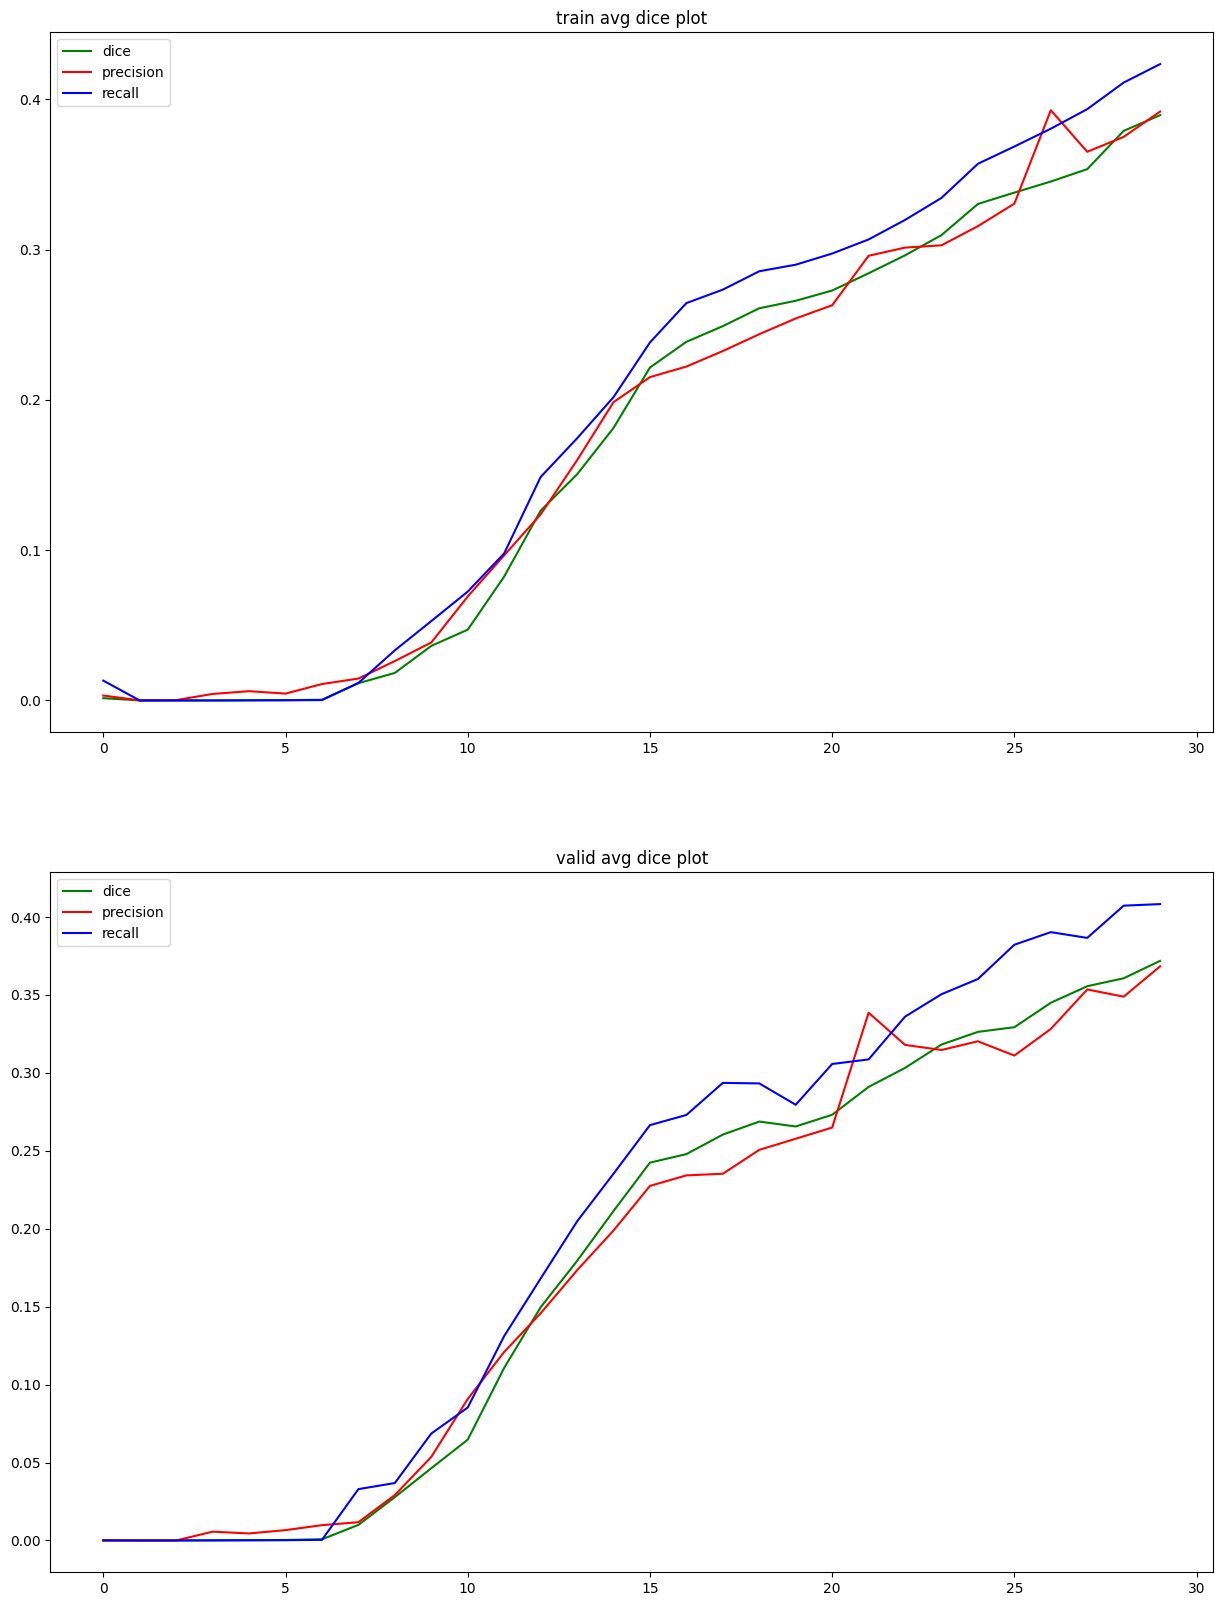

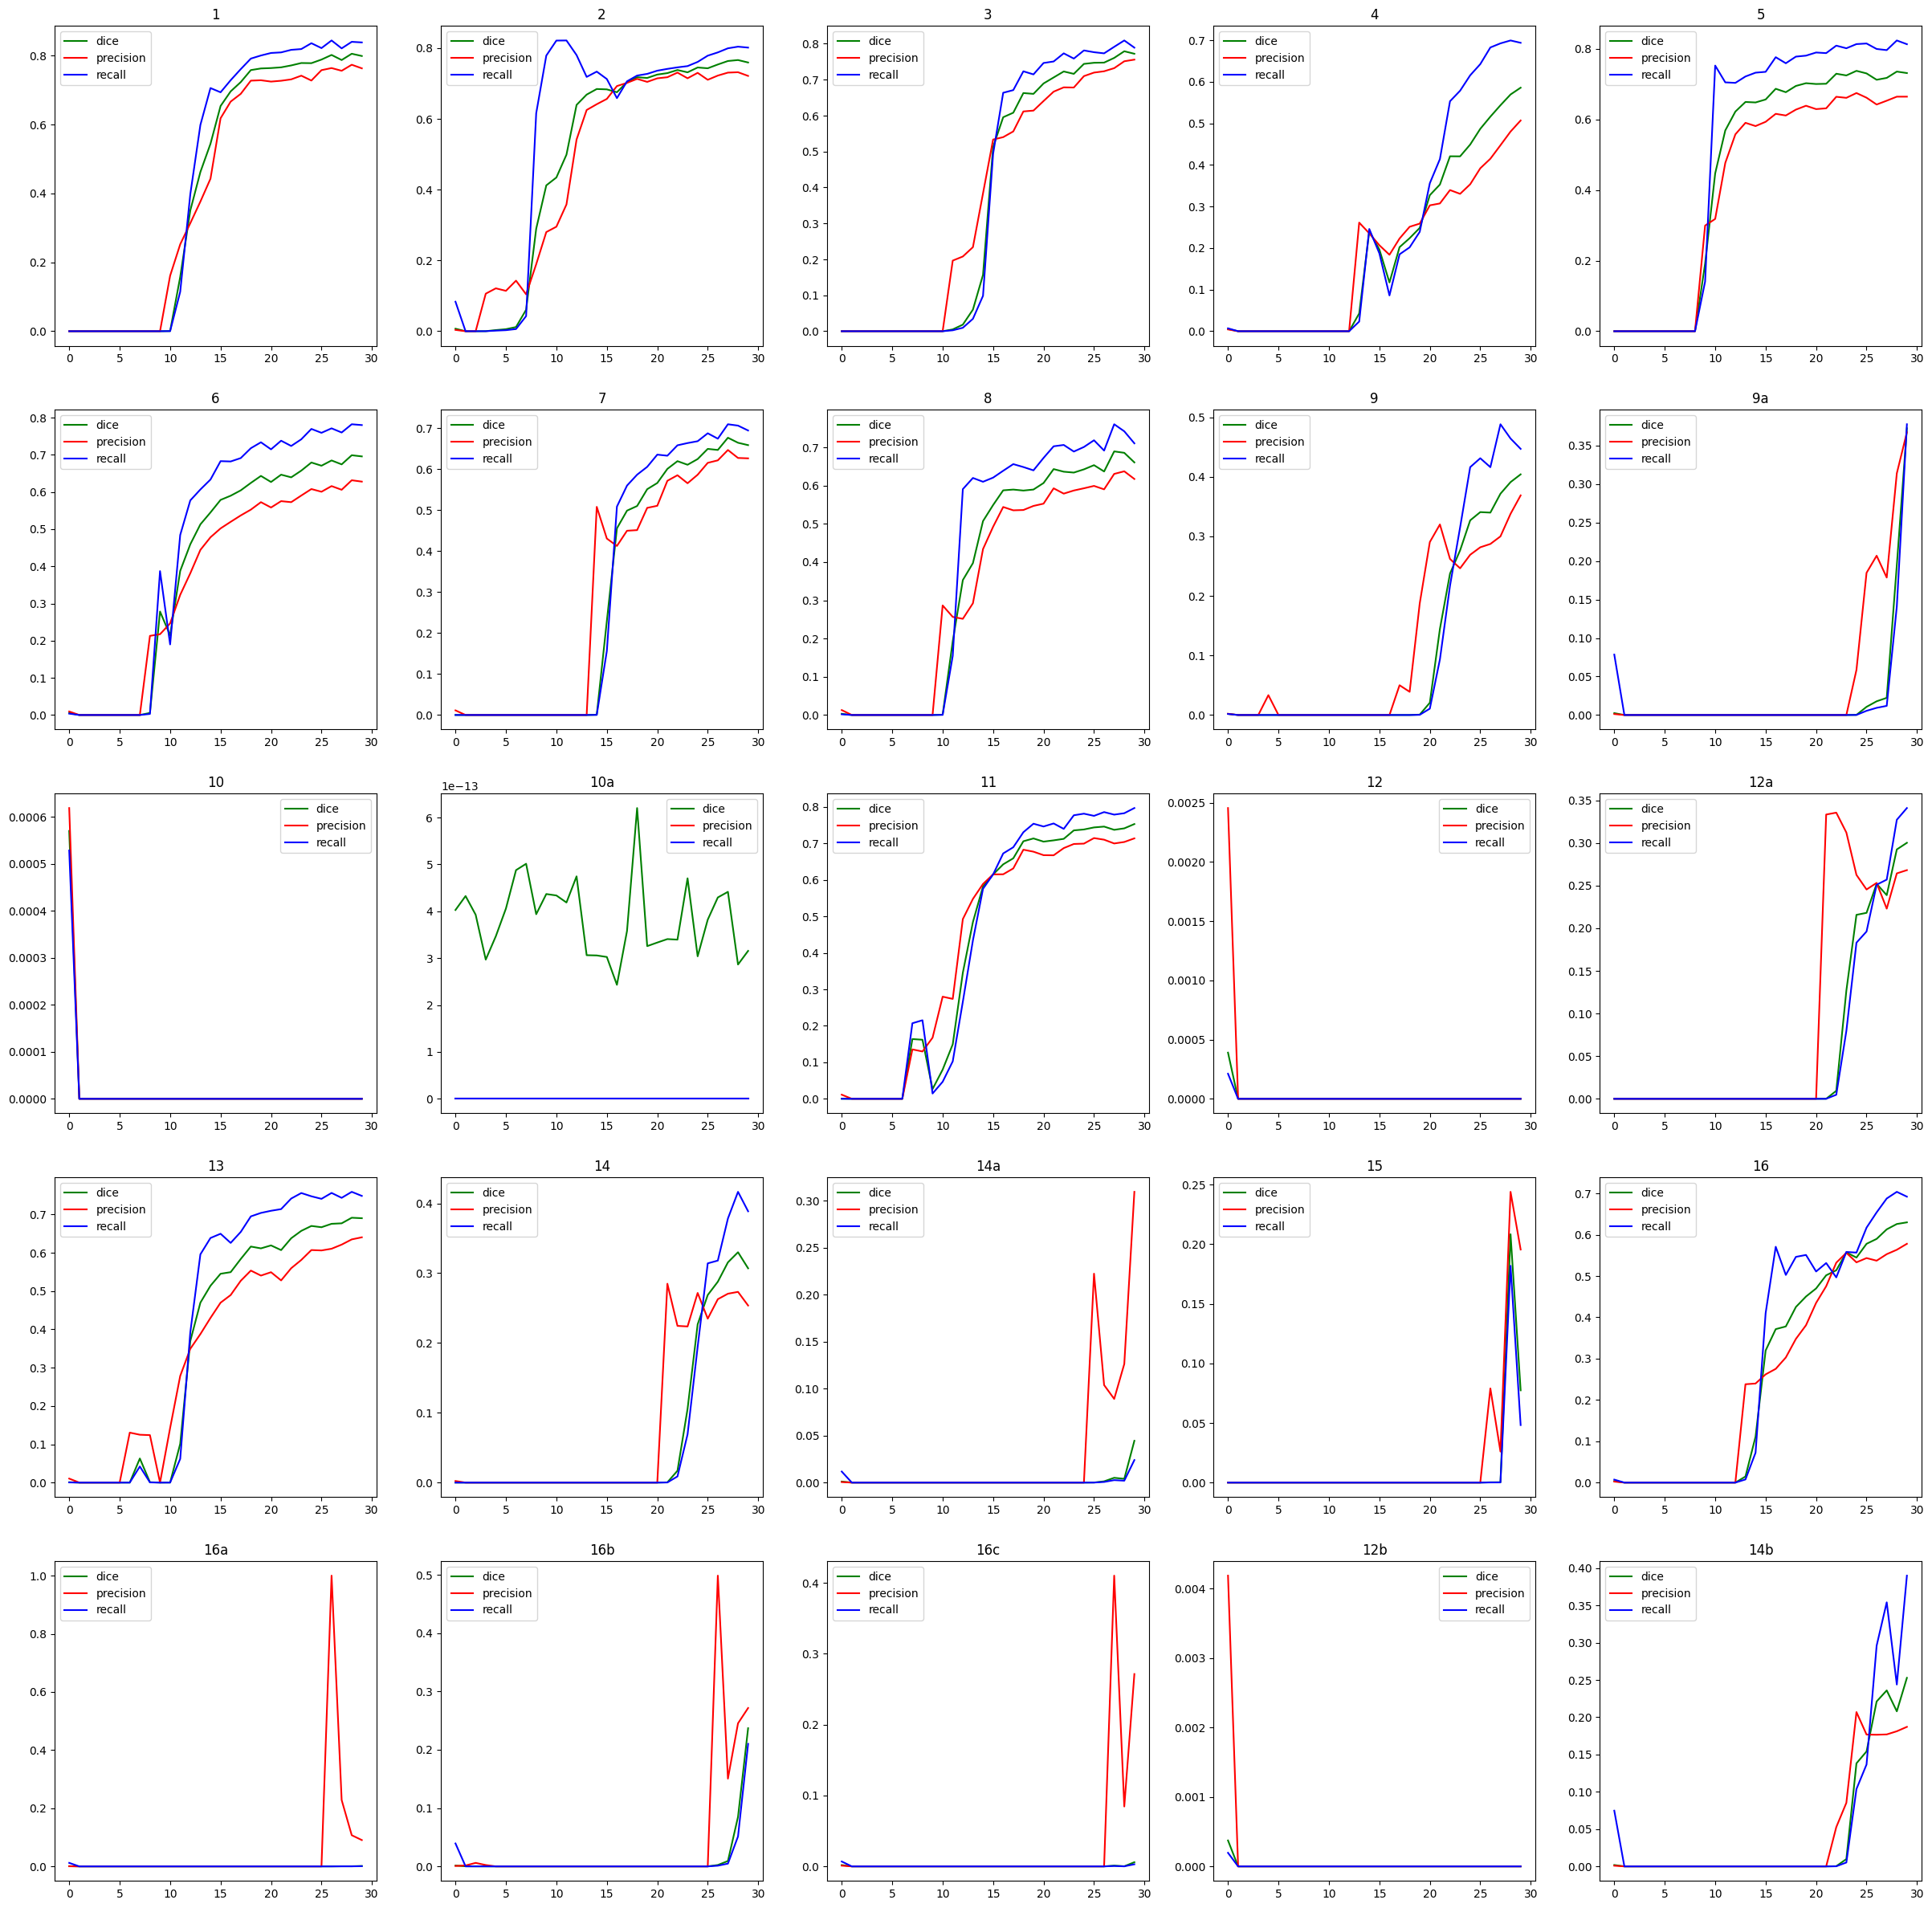

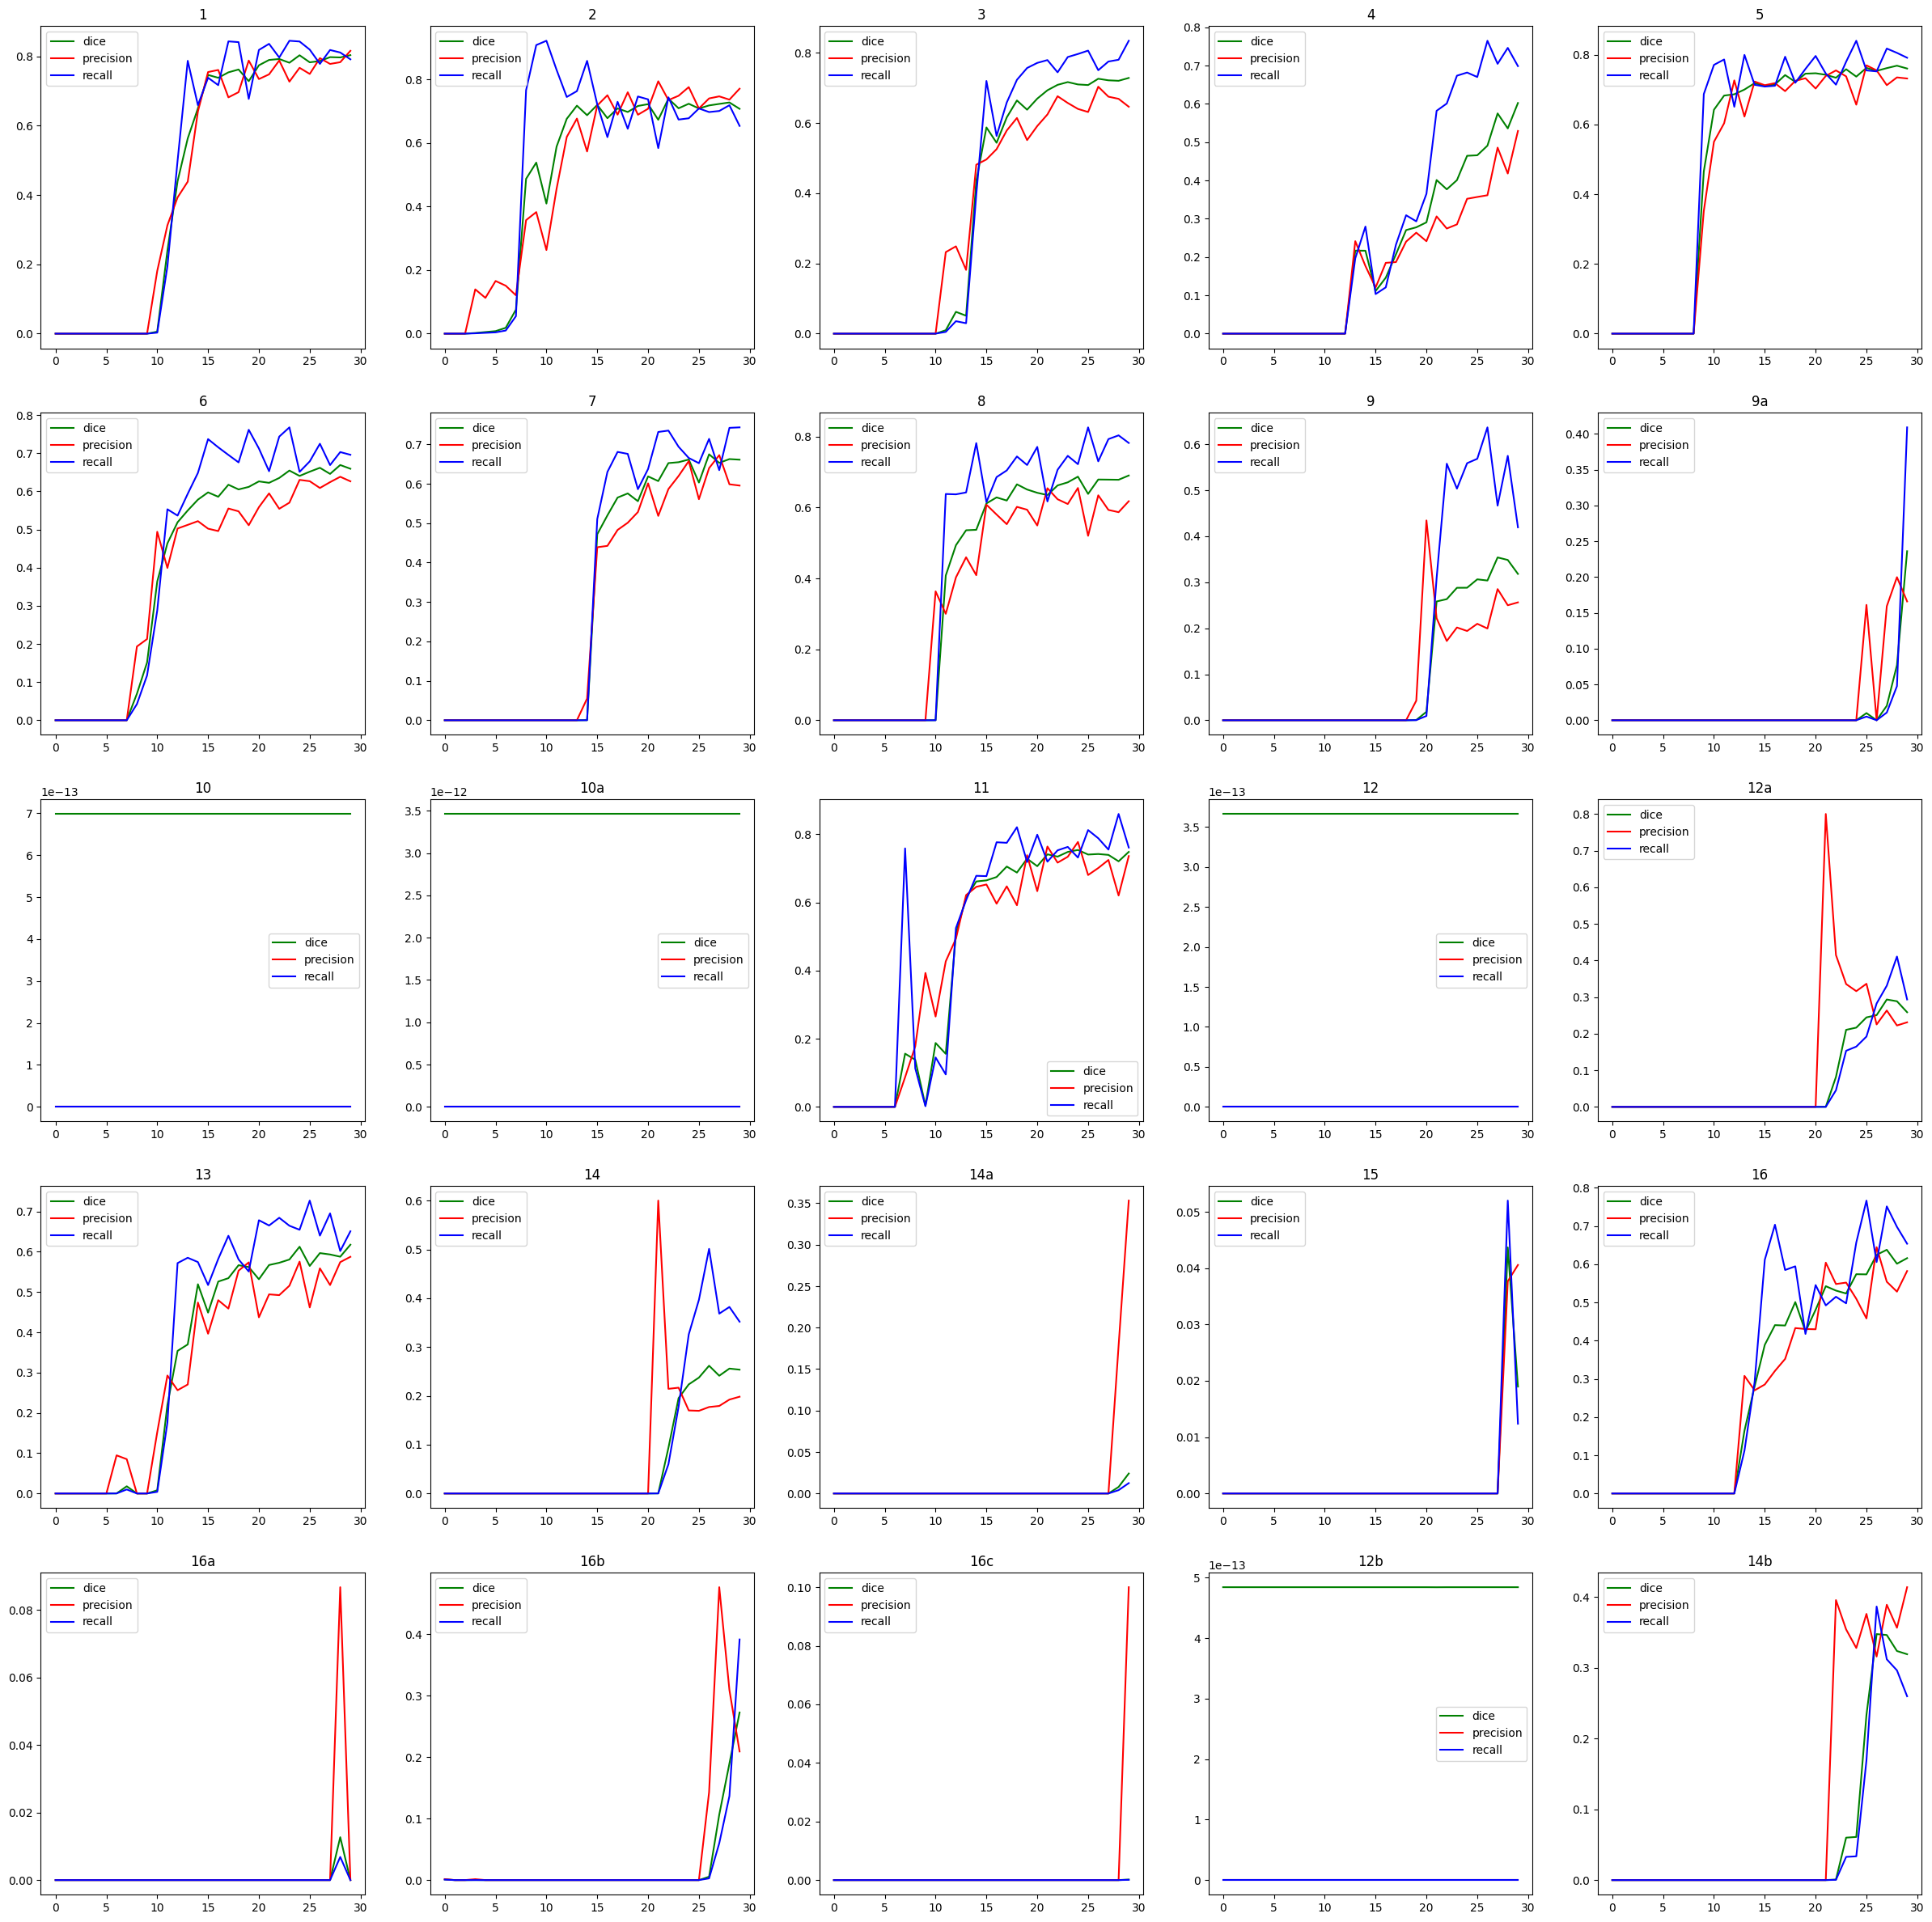

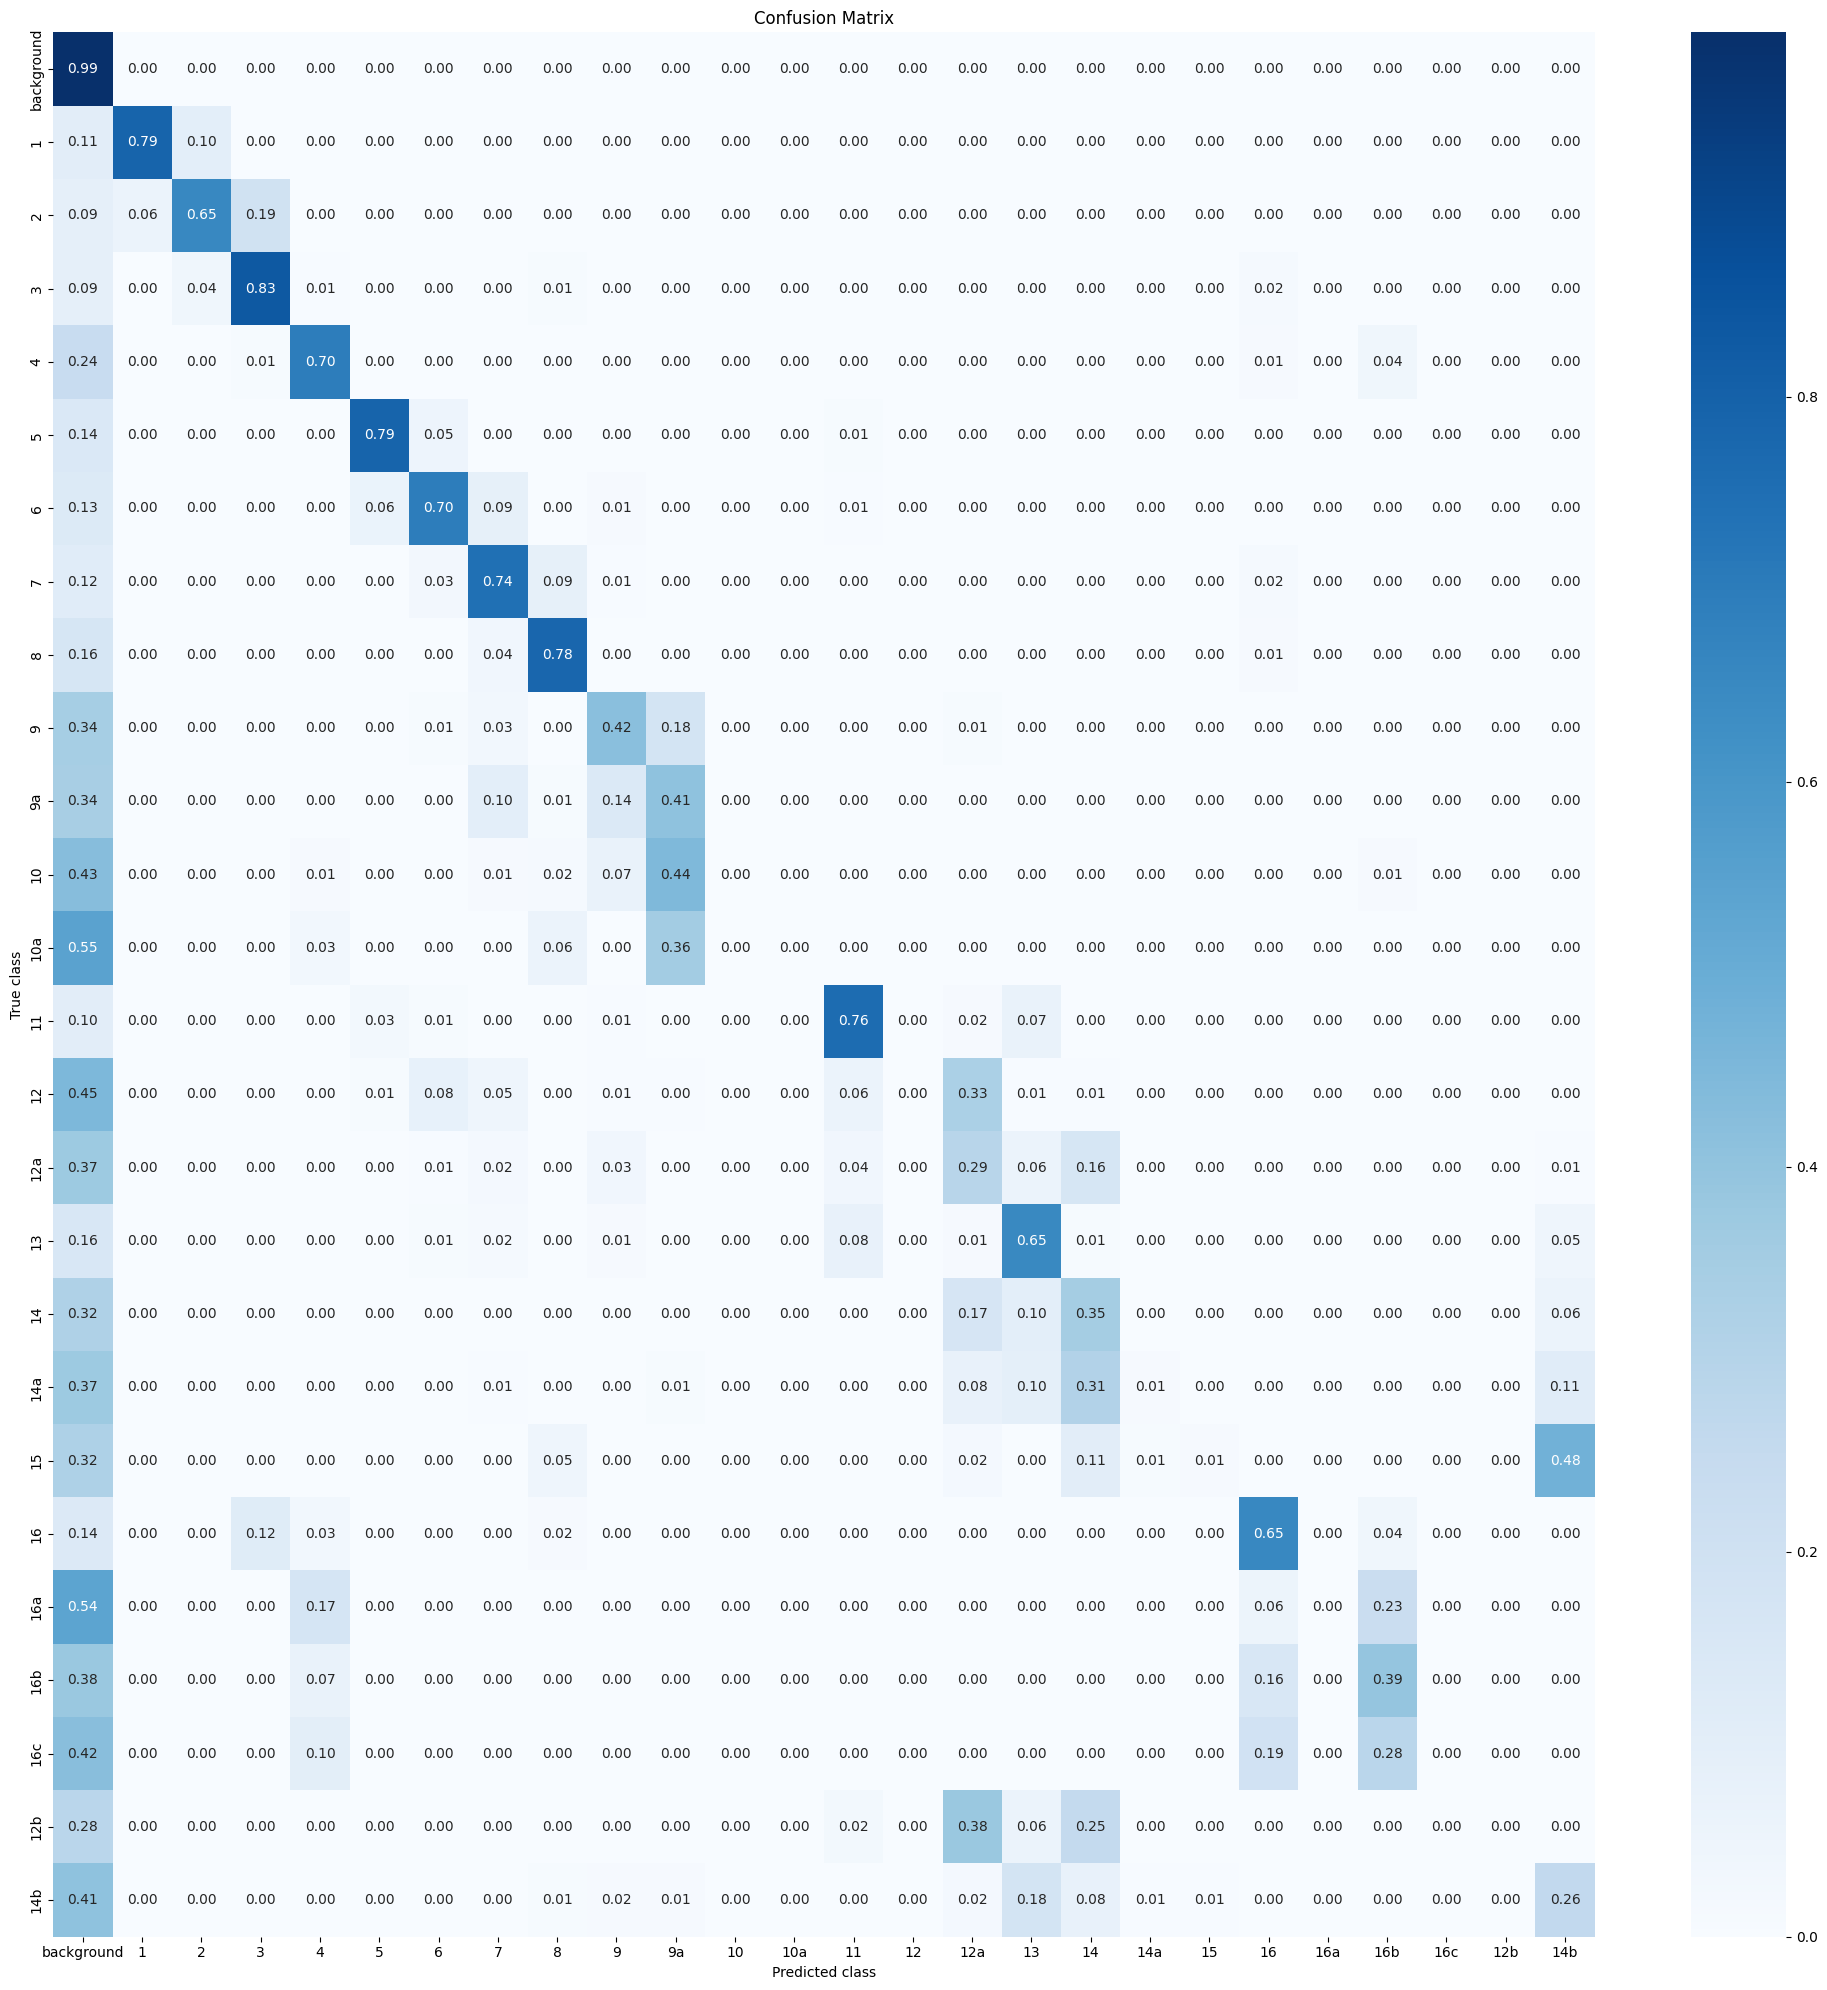

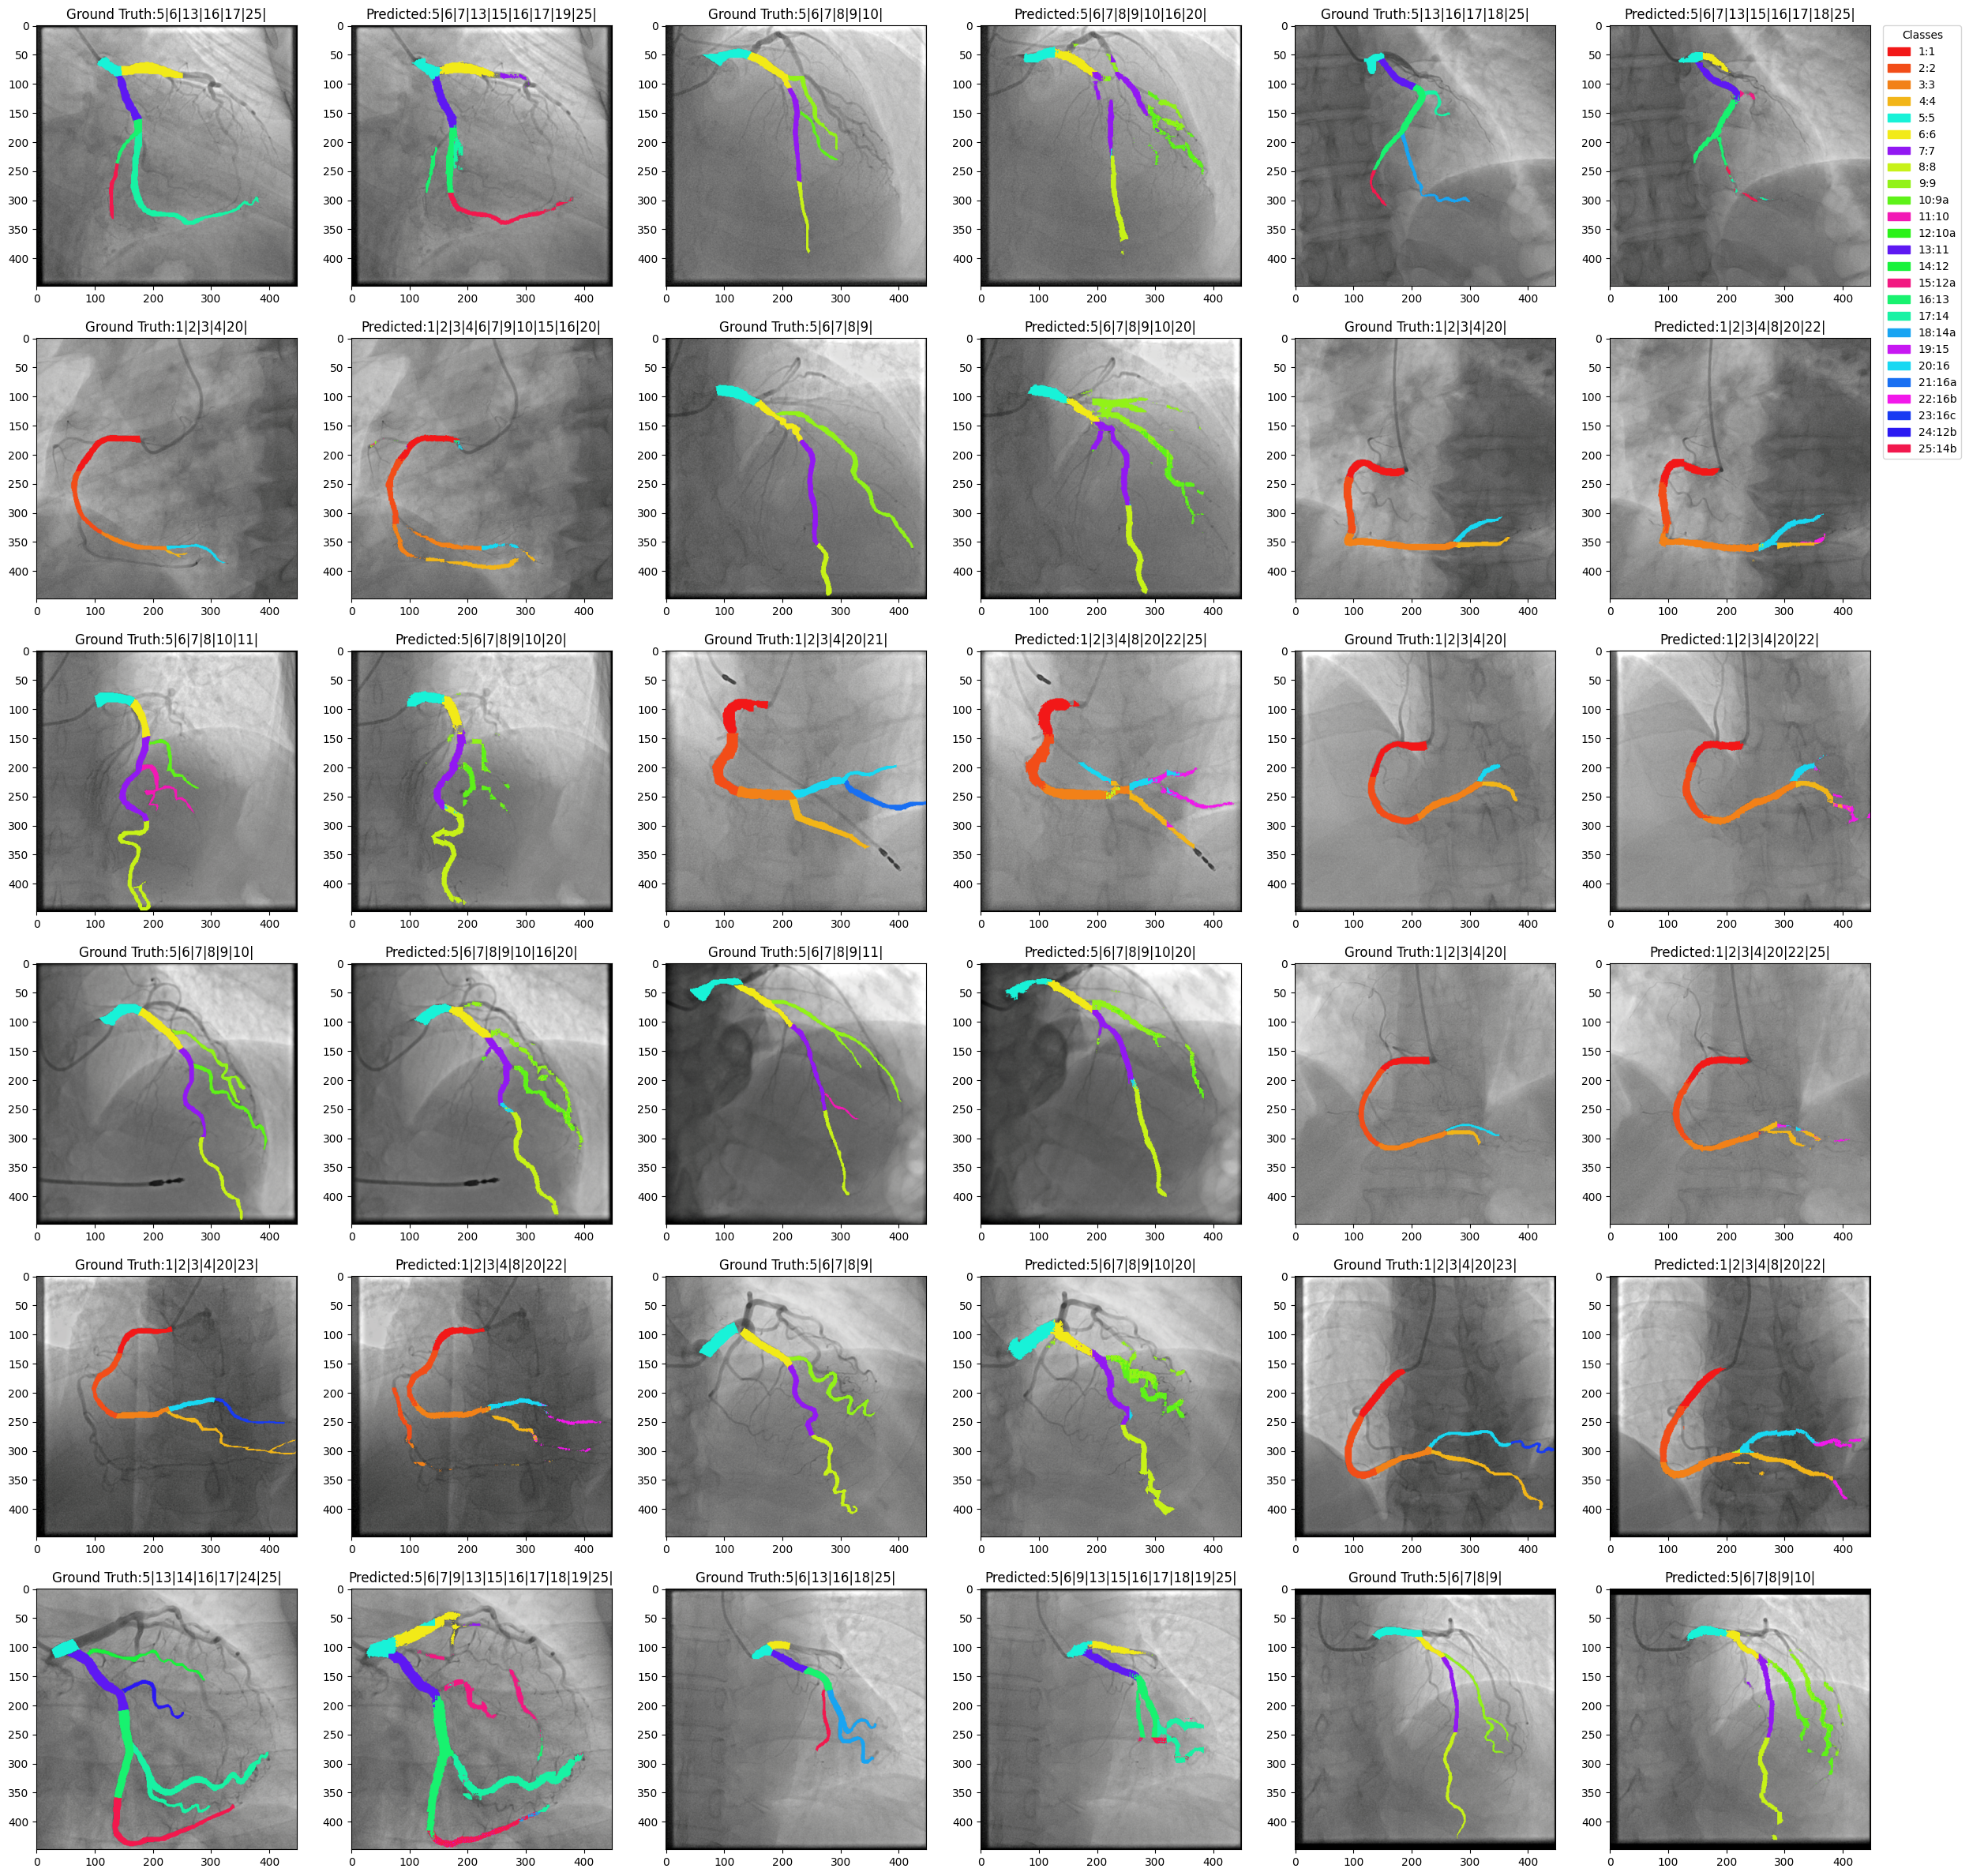

In [12]:
save_full_report(
    recorder= recorder , 
    output_base_path=args["output_base_path"],
    model=best_model,
    valid_loader=valid_loader,
    args=args,
    class_map=class_map,
    name=args["name"],
    mean=IMAGENET_MEAN,
    std=IMAGENET_STD
)